# 模块六 · 监督学习核心算法

## 6.1 线性回归（Linear Regression）

**课时安排：约3课时**

线性回归是最基础、最经典的监督学习算法之一。它试图找到输入特征与输出值之间的**线性关系**，是理解更复杂模型的基石。

---

### 本节目录

1. 假设函数与模型定义
2. 损失函数（MSE均方误差）推导
3. 梯度下降求解参数
4. 多元线性回归与多项式回归
5. 正规方程解法
6. 🧪 从零实现线性回归（NumPy）
7. 📊 Scikit-learn LinearRegression 对比
8. 🔬 可视化损失函数下降曲线与拟合效果
9. 💡 练习题

---

## 1. 假设函数与模型定义

### 什么是线性回归？

线性回归假设输入特征 $\mathbf{x}$ 和输出 $y$ 之间存在**线性关系**：

$$h(\mathbf{x}) = w^T \mathbf{x} + b$$

其中：
- $\mathbf{x} = [x_1, x_2, \dots, x_n]^T$ 是 $n$ 维特征向量
- $\mathbf{w} = [w_1, w_2, \dots, w_n]^T$ 是权重向量
- $b$ 是偏置（截距项）
- $h(\mathbf{x})$ 是模型对输入 $\mathbf{x}$ 的预测值

### 一维情况（简单线性回归）

当只有一个特征时，假设函数简化为：

$$h(x) = wx + b$$

这对应二维平面上的一条直线：$w$ 是斜率，$b$ 是 y 轴截距。

### 向量化表示

为了方便计算，我们常将偏置 $b$ 合并到权重向量中：

$$\hat{\mathbf{w}} = [b, w_1, w_2, \dots, w_n]^T, \quad \hat{\mathbf{x}} = [1, x_1, x_2, \dots, x_n]^T$$

$$h(\mathbf{x}) = \hat{\mathbf{w}}^T \hat{\mathbf{x}}$$

### 目标

给定训练集 $\{\mathbf{x}^{(i)}, y^{(i)}\}_{i=1}^{m}$，找到最优参数 $\mathbf{w}^*, b^*$，使得模型预测值 $h(\mathbf{x}^{(i)})$ 尽可能接近真实值 $y^{(i)}$。

```
  y
  |        *
  |      *   *
  |    *       *
  |  *     ?     *       <-- 我们要拟合的直线
  |*               *
  +-------------------------- x
```

### 直观理解

- **$w$（权重）**：控制直线的斜率，表示特征对预测的影响程度
- **$b$（偏置）**：控制直线的位置，表示当所有特征为0时的基准预测值

---

## 2. 损失函数（MSE均方误差）推导

### 为什么要定义损失函数？

我们需要一个**量化指标**来衡量模型预测的好坏。损失函数越小，说明模型拟合越好。

### 均方误差（Mean Squared Error, MSE）

对于单个样本，其预测误差为：

$$e^{(i)} = h(\mathbf{x}^{(i)}) - y^{(i)}$$

对所有 $m$ 个训练样本取误差平方的均值：

$$J(\mathbf{w}, b) = \frac{1}{m} \sum_{i=1}^{m} \left( h(\mathbf{x}^{(i)}) - y^{(i)} \right)^2$$

展开假设函数：

$$J(\mathbf{w}, b) = \frac{1}{m} \sum_{i=1}^{m} \left( \mathbf{w}^T \mathbf{x}^{(i)} + b - y^{(i)} \right)^2$$

### 为什么选择平方误差？

| 性质 | 说明 |
|------|------|
| **非负性** | $e^2 \geq 0$，误差为零时损失最小 |
| **可导性** | 处处可导，方便梯度计算 |
| **对大误差敏感** | 平方放大了大误差的影响 |
| **凸函数** | MSE关于 $w$ 是凸函数，有唯一全局最小值 |

### 矩阵形式的MSE

设 $X \in \mathbb{R}^{m \times (n+1)}$（含偏置列），$\mathbf{y} \in \mathbb{R}^m$，$\hat{\mathbf{w}} \in \mathbb{R}^{n+1}$：

$$J(\hat{\mathbf{w}}) = \frac{1}{m} \| X\hat{\mathbf{w}} - \mathbf{y} \|^2 = \frac{1}{m}(X\hat{\mathbf{w}} - \mathbf{y})^T(X\hat{\mathbf{w}} - \mathbf{y})$$

### MSE的几何意义

MSE 等价于所有训练样本到拟合直线的**垂直距离的平方和**（除以 $m$）。最小化 MSE 就是找到使这些距离之和最小的直线。

> ⚠️ **注意**：有时也会使用 $\frac{1}{2m}$ 前缀，方便求导后消去系数 $2$。

---

## 3. 梯度下降求解参数

### 梯度下降的直觉

想象你站在一座山的某个位置，蒙上眼睛，只能感受脚下坡度。为了到达谷底（最小值），你应该**沿着最陡峭的下坡方向迈步**。

$$\hat{\mathbf{w}} := \hat{\mathbf{w}} - \alpha \frac{\partial J}{\partial \hat{\mathbf{w}}}$$

其中 $\alpha$ 是**学习率（Learning Rate）**。

### 计算梯度

对 $w_j$ 求偏导：

$$\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} 2 \left( h(\mathbf{x}^{(i)}) - y^{(i)} \right) \cdot x_j^{(i)}$$

对 $b$ 求偏导：

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} 2 \left( h(\mathbf{x}^{(i)}) - y^{(i)} \right)$$

向量化形式（更高效）：

$$\frac{\partial J}{\partial \hat{\mathbf{w}}} = \frac{2}{m} X^T(X\hat{\mathbf{w}} - \mathbf{y})$$

### 梯度下降的三种变体

| 变体 | 说明 | 优点 | 缺点 |
|------|------|------|------|
| **批量梯度下降（BGD）** | 每次使用全部样本 | 稳定、收敛精确 | 计算量大 |
| **随机梯度下降（SGD）** | 每次使用一个样本 | 快速、可在线学习 | 波动大、不稳定 |
| **小批量梯度下降** | 每次使用 mini-batch 个样本 | 兼顾效率与稳定 | 需调超参 |

### 学习率 $\alpha$ 的选择

```
α 太小 → 收敛极慢（走了太多步）
α 适中 → 平稳收敛到最优解 ✅
α 太大 → 可能震荡甚至发散 ❌
```

**经验法则**：从 $\alpha = 0.01$ 开始，按 $\times 3$ 或 $\div 3$ 的方式调整。

### 收敛条件

通常使用以下任一条件停止迭代：
1. **损失变化**：$|J^{(t)} - J^{(t-1)}| < \epsilon$（如 $\epsilon = 10^{-6}$）
2. **最大迭代次数**：$t > t_{\max}$（如 $t_{\max} = 1000$）
3. **梯度范数**：$\|\nabla J\| < \epsilon$

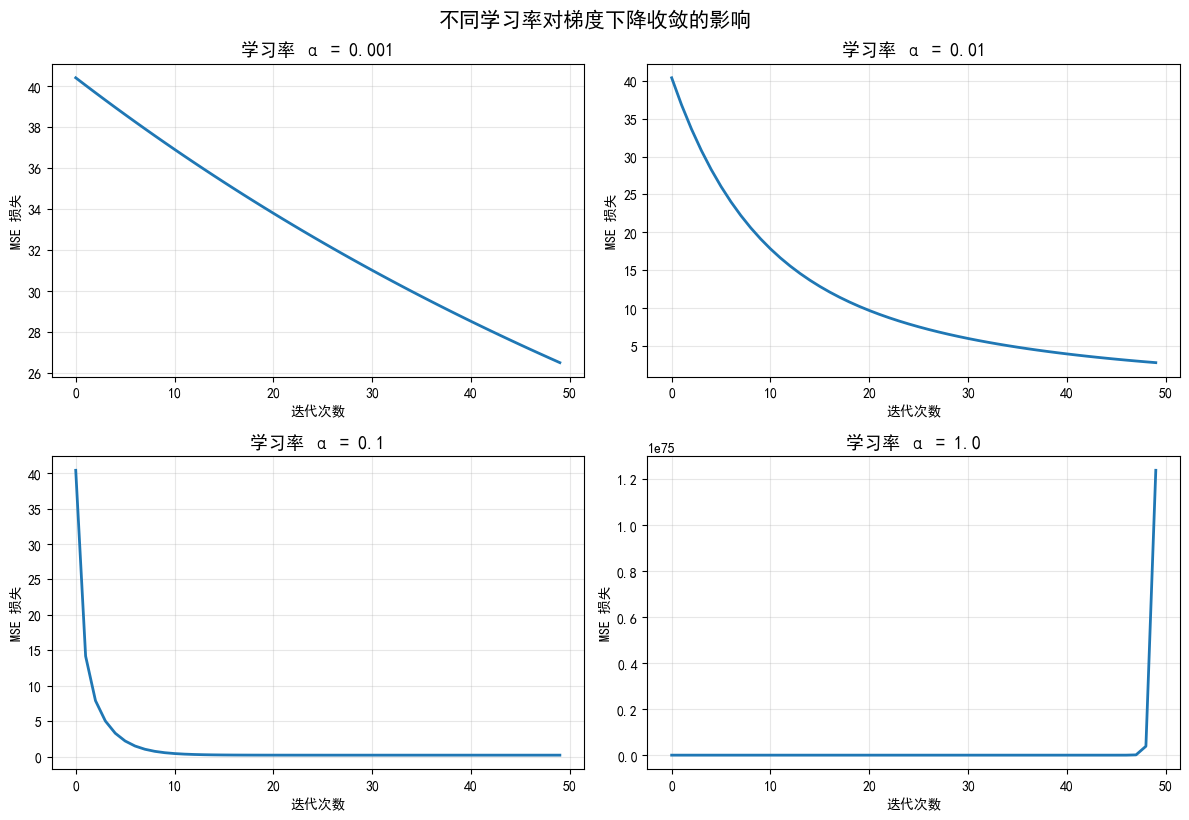

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ========================
# 学习率对收敛的影响演示
# ========================
np.random.seed(42)
X_demo = np.random.randn(100, 1) * 2
y_demo = 3 * X_demo.flatten() + 4 + np.random.randn(100) * 0.5

def gradient_descent_demo(X, y, alpha, n_iter=50):
    m = len(y)
    X_b = np.c_[np.ones((m, 1)), X]  # 添加偏置列
    w = np.zeros((2, 1))
    losses = []
    for _ in range(n_iter):
        y_pred = X_b @ w
        loss = np.mean((y_pred.flatten() - y) ** 2)
        losses.append(loss)
        grad = (2 / m) * X_b.T @ (y_pred.flatten() - y).reshape(-1, 1)
        w -= alpha * grad
    return losses

alphas = [0.001, 0.01, 0.1, 1.0]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, alpha in enumerate(alphas):
    ax = axes[idx // 2][idx % 2]
    losses = gradient_descent_demo(X_demo, y_demo, alpha)
    ax.plot(losses, linewidth=2)
    ax.set_title(f'学习率 α = {alpha}', fontsize=13)
    ax.set_xlabel('迭代次数')
    ax.set_ylabel('MSE 损失')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.suptitle('不同学习率对梯度下降收敛的影响', fontsize=15, y=1.02)
plt.show()

**观察结果**：
- $\alpha = 0.001$：收敛非常缓慢
- $\alpha = 0.01$：收敛平稳 ✅
- $\alpha = 0.1$：收敛较快，但初期有波动
- $\alpha = 1.0$：过大导致发散 ❌

---

## 4. 多元线性回归与多项式回归

### 多元线性回归

当有多个特征时，模型自然扩展为：

$$h(\mathbf{x}) = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$

矩阵形式：$\hat{\mathbf{y}} = X\hat{\mathbf{w}}$

### 多项式回归

通过**特征工程**，将非线性关系转化为线性回归问题：

例如二次多项式：

$$h(x) = w_2 x^2 + w_1 x + b$$

只需构造新特征：$\tilde{x} = [1, x, x^2]^T$，然后做线性回归！

**更高次多项式**：

$$h(x) = \sum_{j=0}^{d} w_j x^j$$

构造特征向量：$\tilde{x} = [1, x, x^2, \dots, x^d]^T$

> 💡 多项式回归本质上是线性回归在**扩展特征空间**上的应用。

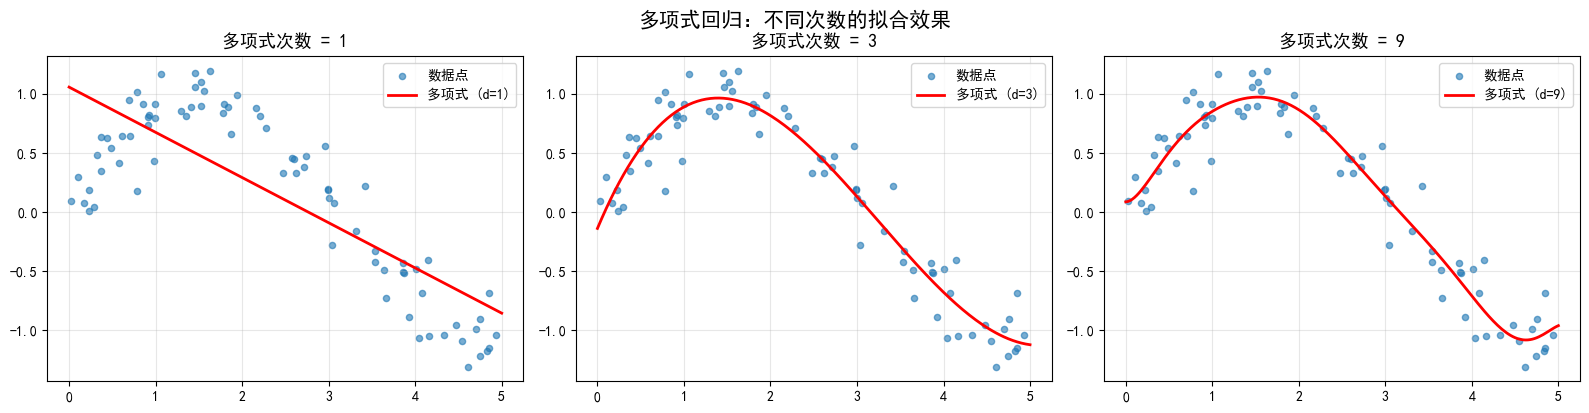

多项式次数越高，拟合越灵活，但容易过拟合！
d=1 欠拟合，d=3 较好，d=9 过拟合（训练数据上表现完美但泛化差）


In [2]:
# ========================
# 多项式回归演示
# ========================
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 生成非线性数据
np.random.seed(42)
X_poly = np.sort(5 * np.random.rand(80, 1), axis=0)
y_poly = np.sin(X_poly).flatten() + np.random.randn(80) * 0.2

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, degree in enumerate([1, 3, 9]):
    ax = axes[idx]
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_transformed = poly_features.fit_transform(X_poly)
    
    model = LinearRegression()
    model.fit(X_transformed, y_poly)
    y_pred = model.predict(X_transformed)
    
    X_plot = np.linspace(0, 5, 200).reshape(-1, 1)
    X_plot_t = poly_features.transform(X_plot)
    y_plot = model.predict(X_plot_t)
    
    ax.scatter(X_poly, y_poly, s=20, alpha=0.6, label='数据点')
    ax.plot(X_plot, y_plot, 'r-', linewidth=2, label=f'多项式 (d={degree})')
    ax.set_title(f'多项式次数 = {degree}', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('多项式回归：不同次数的拟合效果', fontsize=15, y=1.02)
plt.show()

print("多项式次数越高，拟合越灵活，但容易过拟合！")
print("d=1 欠拟合，d=3 较好，d=9 过拟合（训练数据上表现完美但泛化差）")

---

## 5. 正规方程解法

### 原理

对 $J(\hat{\mathbf{w}}) = \frac{1}{m}(X\hat{\mathbf{w}} - \mathbf{y})^T(X\hat{\mathbf{w}} - \mathbf{y})$ 直接求导并令其等于零：

$$\frac{\partial J}{\partial \hat{\mathbf{w}}} = \frac{2}{m}X^T(X\hat{\mathbf{w}} - \mathbf{y}) = \mathbf{0}$$

解得：

$$\hat{\mathbf{w}}^* = (X^T X)^{-1} X^T \mathbf{y}$$

> 这就是**正规方程（Normal Equation）**，无需迭代，一步到位！

### 正规方程 vs 梯度下降

| 对比项 | 正规方程 | 梯度下降 |
|--------|----------|----------|
| **求解方式** | 直接求解析解 | 迭代优化 |
| **时间复杂度** | $O(n^3)$（矩阵求逆） | $O(kmn)$（$k$ 次迭代） |
| **适用场景** | 特征数 $n$ 较小时 | $n$ 很大时（如 $n > 10000$） |
| **超参数** | 无需调学习率 | 需调 $\alpha$ |
| **特征缩放** | 不需要 | **必须**做特征缩放 |
| **奇异矩阵** | $X^T X$ 不可逆时失效 | 不受影响 |

In [3]:
# ========================
# 正规方程 vs 梯度下降 对比
# ========================
np.random.seed(42)

# 生成回归数据
m_samples = 200
X_norm = np.random.randn(m_samples, 1) * 3
y_norm = 2.5 * X_norm.flatten() + 1.5 + np.random.randn(m_samples) * 0.8

X_b = np.c_[np.ones((m_samples, 1)), X_norm]  # [1, x]

# --- 正规方程 ---
w_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_norm
print("=== 正规方程求解 ===")
print(f"w = {w_normal[1]:.4f}, b = {w_normal[0]:.4f}")

# --- 梯度下降 ---
alpha = 0.01
n_iters = 1000
w_gd = np.zeros(2)
gd_losses = []
for i in range(n_iters):
    y_pred = X_b @ w_gd
    loss = np.mean((y_pred - y_norm) ** 2)
    gd_losses.append(loss)
    grad = (2 / m_samples) * X_b.T @ (y_pred - y_norm)
    w_gd -= alpha * grad

print(f"\n=== 梯度下降求解 ({n_iters} 次迭代, α={alpha}) ===")
print(f"w = {w_gd[1]:.4f}, b = {w_gd[0]:.4f}")
print(f"最终MSE = {gd_losses[-1]:.6f}")
print(f"\n两种方法结果差异: |Δw| = {abs(w_normal[1]-w_gd[1]):.6f}, |Δb| = {abs(w_normal[0]-w_gd[0]):.6f}")

=== 正规方程求解 ===
w = 2.5269, b = 1.5720

=== 梯度下降求解 (1000 次迭代, α=0.01) ===
w = 2.5269, b = 1.5720
最终MSE = 0.614740

两种方法结果差异: |Δw| = 0.000000, |Δb| = 0.000000


---

## 6. 🧪 从零实现线性回归（NumPy）

下面我们用纯 NumPy 完整实现一个支持梯度下降的线性回归类。

In [4]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionFromScratch:
    """
    从零实现的线性回归（梯度下降法）
    
    参数:
        learning_rate : float, 学习率 (默认 0.01)
        n_iterations : int, 最大迭代次数 (默认 1000)
        tolerance    : float, 收敛阈值 (默认 1e-7)
        verbose       : bool, 是否打印训练信息
    """
    
    def __init__(self, learning_rate=0.01, n_iterations=1000, tolerance=1e-7, verbose=False):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.tolerance = tolerance
        self.verbose = verbose
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def _compute_loss(self, X, y):
        """计算MSE损失"""
        m = len(y)
        y_pred = X @ self.weights + self.bias
        return np.mean((y_pred - y) ** 2)
    
    def fit(self, X, y):
        """
        训练模型（批量梯度下降）
        
        参数:
            X : ndarray, shape (m, n), 训练特征矩阵
            y : ndarray, shape (m,), 训练标签
        """
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0.0
        self.loss_history = []
        
        for iteration in range(self.n_iterations):
            # 前向传播
            y_pred = X @ self.weights + self.bias
            
            # 计算损失
            loss = np.mean((y_pred - y) ** 2)
            self.loss_history.append(loss)
            
            # 计算梯度
            dw = (2 / m) * X.T @ (y_pred - y)
            db = (2 / m) * np.sum(y_pred - y)
            
            # 更新参数
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # 收敛检查
            if iteration > 0 and abs(self.loss_history[-2] - loss) < self.tolerance:
                if self.verbose:
                    print(f"  在第 {iteration} 次迭代收敛！MSE = {loss:.8f}")
                break
        
        if self.verbose:
            print(f"  训练完成！共 {len(self.loss_history)} 次迭代, 最终MSE = {loss:.8f}")
        
        return self
    
    def predict(self, X):
        """预测"""
        return X @ self.weights + self.bias
    
    def score(self, X, y):
        """计算 R² 决定系数"""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot

print("✅ LinearRegressionFromScratch 类定义完成！")

✅ LinearRegressionFromScratch 类定义完成！


In [5]:
# ========================
# 训练 & 评估
# ========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 生成数据
np.random.seed(42)
n_features = 3
m_samples = 500
X_data = np.random.randn(m_samples, n_features) * 2
true_weights = np.array([3.0, -1.5, 2.0])
y_data = X_data @ true_weights + 5.0 + np.random.randn(m_samples) * 1.0

# 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)

# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 从零实现训练 ---
print("【从零实现】线性回归训练：")
model_scratch = LinearRegressionFromScratch(
    learning_rate=0.05, n_iterations=2000, verbose=True
)
model_scratch.fit(X_train_scaled, y_train)

y_pred_scratch = model_scratch.predict(X_test_scaled)
r2_scratch = model_scratch.score(X_test_scaled, y_test)
mse_scratch = np.mean((y_pred_scratch - y_test) ** 2)

print(f"\n  测试集 MSE = {mse_scratch:.4f}")
print(f"  测试集 R²  = {r2_scratch:.4f}")
print(f"  学到的权重 = {model_scratch.weights}")
print(f"  学到的偏置 = {model_scratch.bias:.4f}")

【从零实现】线性回归训练：
  在第 91 次迭代收敛！MSE = 0.94625376
  训练完成！共 92 次迭代, 最终MSE = 0.94625376

  测试集 MSE = 1.0256
  测试集 R²  = 0.9826
  学到的权重 = [ 5.62753961 -3.03008749  3.99789014]
  学到的偏置 = 5.9760


In [6]:
# ========================
# Scikit-learn LinearRegression 对比
# ========================
from sklearn.linear_model import LinearRegression as SKLinearRegression

print("【Scikit-learn】线性回归训练：")
model_sk = SKLinearRegression()
model_sk.fit(X_train_scaled, y_train)

y_pred_sk = model_sk.predict(X_test_scaled)
r2_sk = model_sk.score(X_test_scaled, y_test)
mse_sk = np.mean((y_pred_sk - y_test) ** 2)

print(f"\n  测试集 MSE = {mse_sk:.4f}")
print(f"  测试集 R²  = {r2_sk:.4f}")
print(f"  学到的权重 = {model_sk.coef_}")
print(f"  学到的偏置 = {model_sk.intercept_:.4f}")

# --- 对比结果 ---
print("\n" + "=" * 55)
print("           从零实现    vs    Scikit-learn")
print("=" * 55)
print(f"  MSE :    {mse_scratch:.4f}    vs    {mse_sk:.4f}")
print(f"  R²  :    {r2_scratch:.4f}    vs    {r2_sk:.4f}")
print("=" * 55)
print("✅ 两种方法的结果非常接近！")

【Scikit-learn】线性回归训练：

  测试集 MSE = 1.0256
  测试集 R²  = 0.9826
  学到的权重 = [ 5.62777043 -3.03023068  3.99818186]
  学到的偏置 = 5.9764

           从零实现    vs    Scikit-learn
  MSE :    1.0256    vs    1.0256
  R²  :    0.9826    vs    0.9826
✅ 两种方法的结果非常接近！


---

## 7. 📊 可视化：损失函数下降曲线与拟合效果

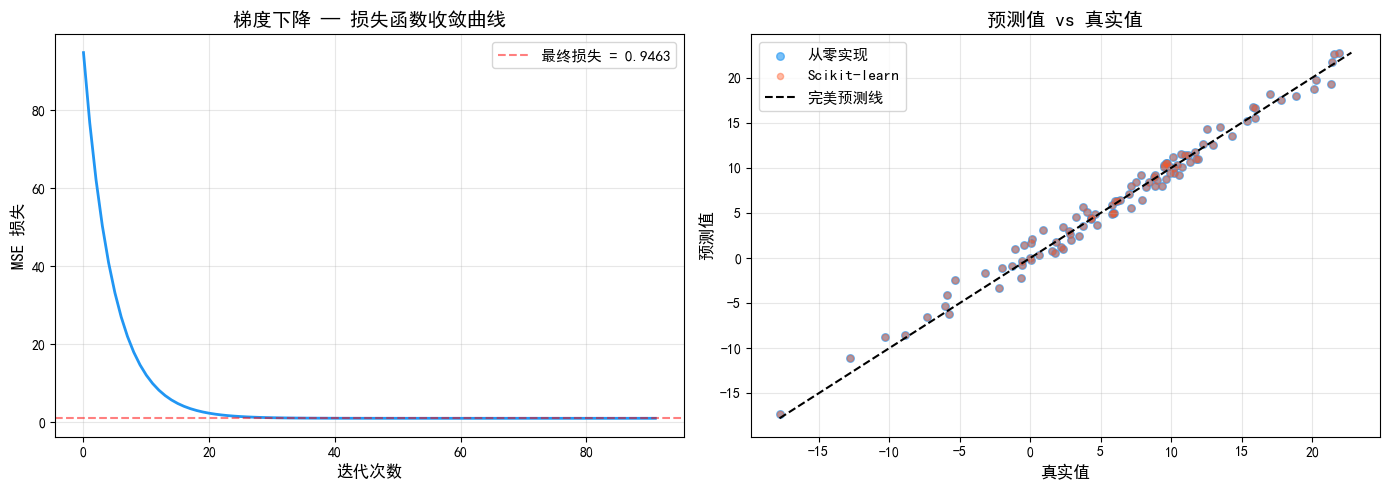

In [7]:
# ========================
# 可视化1: 损失函数下降曲线 + 预测值 vs 真实值
# ========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 损失下降曲线
ax1 = axes[0]
ax1.plot(model_scratch.loss_history, linewidth=2, color='#2196F3')
ax1.set_xlabel('迭代次数', fontsize=12)
ax1.set_ylabel('MSE 损失', fontsize=12)
ax1.set_title('梯度下降 — 损失函数收敛曲线', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=model_scratch.loss_history[-1], color='r', linestyle='--', alpha=0.5,
            label=f'最终损失 = {model_scratch.loss_history[-1]:.4f}')
ax1.legend(fontsize=11)

# 预测值 vs 真实值 散点图
ax2 = axes[1]
ax2.scatter(y_test, y_pred_scratch, alpha=0.6, s=30, color='#2196F3', label='从零实现')
ax2.scatter(y_test, y_pred_sk, alpha=0.4, s=20, color='#FF5722', label='Scikit-learn')
min_val = min(y_test.min(), y_pred_scratch.min())
max_val = max(y_test.max(), y_pred_scratch.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='完美预测线')
ax2.set_xlabel('真实值', fontsize=12)
ax2.set_ylabel('预测值', fontsize=12)
ax2.set_title('预测值 vs 真实值', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

  在第 411 次迭代收敛！MSE = 1.03635178
  训练完成！共 412 次迭代, 最终MSE = 1.03635178


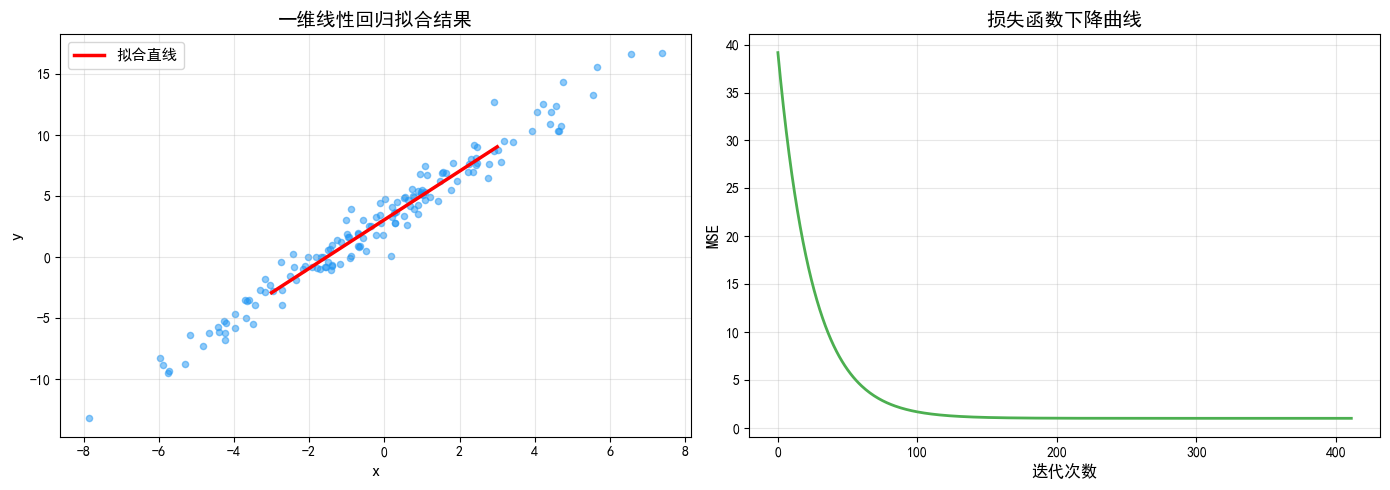


✅ 一维拟合结果: w ≈ 5.61, b ≈ 2.58
   R² = 0.9681


In [8]:
# ========================
# 可视化2: 简单一维线性回归拟合图
# ========================
np.random.seed(42)
X_1d = np.random.randn(150, 1) * 3
y_1d = 2.0 * X_1d.flatten() + 3.0 + np.random.randn(150) * 1.0

model_1d = LinearRegressionFromScratch(learning_rate=0.01, n_iterations=1000, verbose=True)
scaler_1d = StandardScaler()
X_1d_scaled = scaler_1d.fit_transform(X_1d)
model_1d.fit(X_1d_scaled, y_1d)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 拟合直线
ax1 = axes[0]
x_line = np.linspace(-3, 3, 200).reshape(-1, 1)
x_line_scaled = scaler_1d.transform(x_line)
y_line = model_1d.predict(x_line_scaled)

ax1.scatter(X_1d, y_1d, s=20, alpha=0.5, color='#2196F3')
ax1.plot(x_line, y_line, 'r-', linewidth=2.5, label='拟合直线')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('一维线性回归拟合结果', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 损失曲线
ax2 = axes[1]
ax2.plot(model_1d.loss_history, linewidth=2, color='#4CAF50')
ax2.set_xlabel('迭代次数', fontsize=12)
ax2.set_ylabel('MSE', fontsize=12)
ax2.set_title('损失函数下降曲线', fontsize=14)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✅ 一维拟合结果: w ≈ {model_1d.weights[0]:.2f}, b ≈ {model_1d.bias:.2f}")
print(f"   R² = {model_1d.score(X_1d_scaled, y_1d):.4f}")

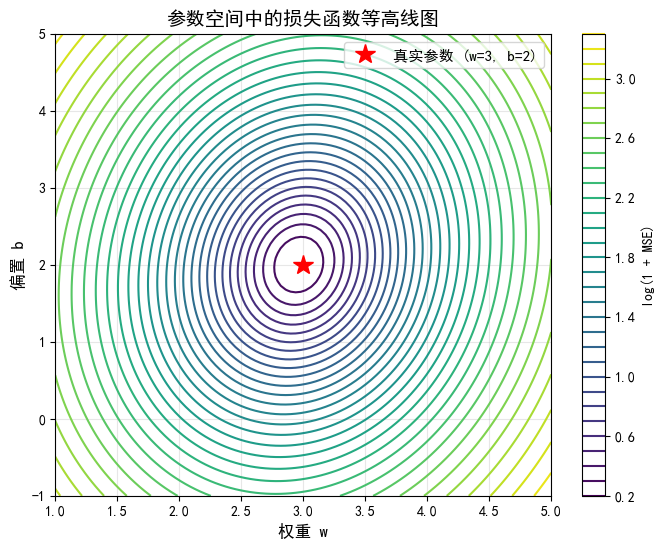

等高线呈椭圆形（因为MSE是凸函数），最低点对应最优参数。


In [9]:
# ========================
# 可视化3: 参数空间中的损失函数等高线
# ========================
np.random.seed(42)
X_c = np.random.randn(100, 1) * 2
y_c = 3 * X_c.flatten() + 2 + np.random.randn(100) * 0.5
X_c_b = np.c_[np.ones((100, 1)), X_c]

# 在 (w, b) 空间计算损失
w_range = np.linspace(1, 5, 100)
b_range = np.linspace(-1, 5, 100)
W, B = np.meshgrid(w_range, b_range)
Loss = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        pred = X_c_b @ np.array([B[i, j], W[i, j]])
        Loss[i, j] = np.mean((pred - y_c) ** 2)

fig, ax = plt.subplots(figsize=(8, 6))
CS = ax.contour(W, B, np.log1p(Loss), levels=30, cmap='viridis')
plt.colorbar(CS, ax=ax, label='log(1 + MSE)')
ax.set_xlabel('权重 w', fontsize=12)
ax.set_ylabel('偏置 b', fontsize=12)
ax.set_title('参数空间中的损失函数等高线图', fontsize=14)
ax.plot(3, 2, 'r*', markersize=15, label='真实参数 (w=3, b=2)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.show()

print("等高线呈椭圆形（因为MSE是凸函数），最低点对应最优参数。")

---

## 8. 💡 练习题

### 练习1：手写梯度下降（基础）

完成以下代码，实现一维线性回归的梯度下降：

```python
def simple_gd(X, y, alpha=0.01, n_iters=100):
    w, b = 0.0, 0.0
    m = len(y)
    for _ in range(n_iters):
        y_pred = w * X + b
        # TODO: 计算梯度并更新参数
        # dw = ???
        # db = ???
        # w -= alpha * dw
        # b -= alpha * db
    return w, b
```

### 练习2：特征缩放实验

使用未标准化的数据和标准化后的数据分别训练线性回归模型，对比：
1. 收敛速度（损失下降曲线）
2. 最终MSE
3. 讨论为什么特征缩放对梯度下降很重要

### 练习3：多项式回归实验

使用 `make_regression` 生成非线性数据，尝试不同多项式次数（1, 2, 5, 10），绘制拟合曲线，观察过拟合现象。

### 练习4：波士顿房价预测（选做）

使用 Scikit-learn 的 `fetch_california_housing` 数据集，完成完整的线性回归建模流程（数据探索、特征工程、模型训练、评估）。

---

> 📌 **本节要点回顾**：
> - 线性回归假设 $h(x) = w^T x + b$，通过最小化MSE来学习参数
> - 梯度下降是迭代优化方法，学习率选择至关重要
> - 正规方程给出解析解，但计算开销大
> - 多项式回归通过特征工程处理非线性关系
> - 特征缩放对梯度下降的收敛速度影响极大